# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1319s 8us/step


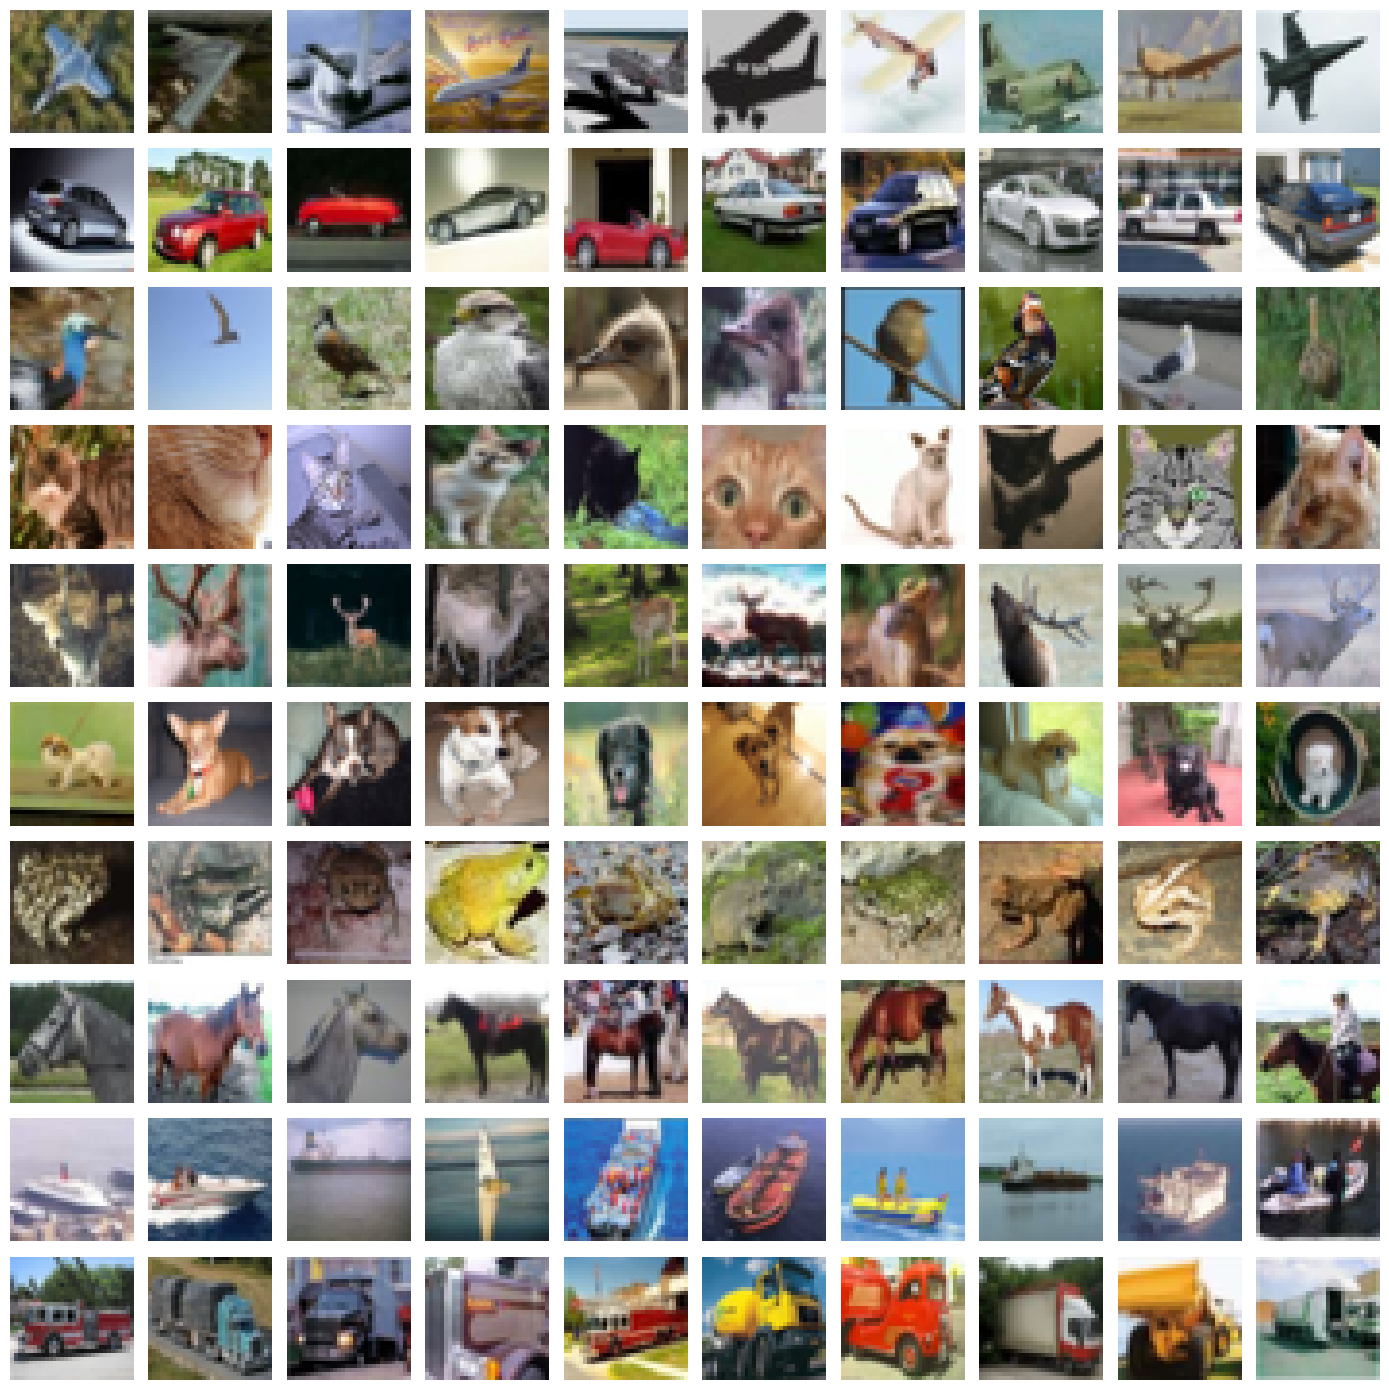

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Show 10 random examples from each CIFAR-10 class.
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
rng = np.random.default_rng(42)
fig, axes = plt.subplots(10, 10, figsize=(14, 14))
for class_index, class_name in enumerate(class_names):
    class_indices = np.flatnonzero(y_train[:, 0] == class_index)
    sample_indices = rng.choice(class_indices, size=10, replace=False)
    for column, sample_index in enumerate(sample_indices):
        axes[class_index, column].imshow(x_train[sample_index])
        axes[class_index, column].axis("off")
        if column == 0:
            axes[class_index, column].set_ylabel(class_name, rotation=0, labelpad=35)
plt.tight_layout()
plt.show()

# Convert labels to one-hot vectors and scale image pixels to [0, 1].
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [5]:
from keras.backend import clear_session
clear_session()

In [3]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history_baseline = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/50
88/88 - 6s - 69ms/step - accuracy: 0.1715 - loss: 2.2684 - val_accuracy: 0.2380 - val_loss: 2.2267
Epoch 2/50
88/88 - 1s - 10ms/step - accuracy: 0.2578 - loss: 2.1685 - val_accuracy: 0.2752 - val_loss: 2.1077
Epoch 3/50
88/88 - 1s - 10ms/step - accuracy: 0.2959 - loss: 2.0501 - val_accuracy: 0.3046 - val_loss: 2.0036
Epoch 4/50
88/88 - 1s - 12ms/step - accuracy: 0.3230 - loss: 1.9623 - val_accuracy: 0.3202 - val_loss: 1.9415
Epoch 5/50
88/88 - 1s - 12ms/step - accuracy: 0.3380 - loss: 1.9074 - val_accuracy: 0.3314 - val_loss: 1.8992
Epoch 6/50
88/88 - 1s - 13ms/step - accuracy: 0.3504 - loss: 1.8695 - val_accuracy: 0.3530 - val_loss: 1.8696
Epoch 7/50
88/88 - 1s - 10ms/step - accuracy: 0.3630 - loss: 1.8377 - val_accuracy: 0.3628 - val_loss: 1.8361
Epoch 8/50
88/88 - 1s - 10ms/step - accuracy: 0.3684 - loss: 1.8180 - val_accuracy: 0.3682 - val_loss: 1.8135
Epoch 9/50
88/88 - 1s - 10ms/step - accuracy: 0.3786 - loss: 1.7902 - val_accuracy: 0.3464 - val_loss: 1.8507
Epoch 10/5

*   Plot the cross entropy loss curve and the accuracy curve

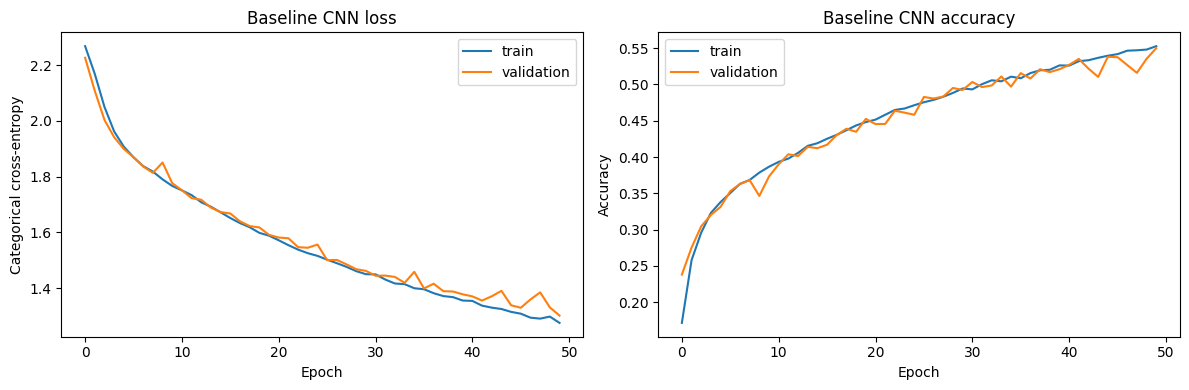

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_baseline.history["loss"], label="train")
axes[0].plot(history_baseline.history["val_loss"], label="validation")
axes[0].set(title="Baseline CNN loss", xlabel="Epoch", ylabel="Categorical cross-entropy")
axes[0].legend()
axes[1].plot(history_baseline.history["accuracy"], label="train")
axes[1].plot(history_baseline.history["val_accuracy"], label="validation")
axes[1].set(title="Baseline CNN accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [9]:
from keras.backend import clear_session
clear_session()

In [6]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history_vgg = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/50
88/88 - 10s - 117ms/step - accuracy: 0.1809 - loss: 2.2351 - val_accuracy: 0.2426 - val_loss: 2.1414
Epoch 2/50
88/88 - 2s - 25ms/step - accuracy: 0.2757 - loss: 2.0559 - val_accuracy: 0.2906 - val_loss: 2.0011
Epoch 3/50
88/88 - 2s - 26ms/step - accuracy: 0.3065 - loss: 1.9614 - val_accuracy: 0.3180 - val_loss: 1.9277
Epoch 4/50
88/88 - 2s - 26ms/step - accuracy: 0.3341 - loss: 1.8956 - val_accuracy: 0.3498 - val_loss: 1.8787
Epoch 5/50
88/88 - 2s - 27ms/step - accuracy: 0.3546 - loss: 1.8441 - val_accuracy: 0.3348 - val_loss: 1.8789
Epoch 6/50
88/88 - 2s - 26ms/step - accuracy: 0.3667 - loss: 1.8029 - val_accuracy: 0.3818 - val_loss: 1.7957
Epoch 7/50
88/88 - 2s - 26ms/step - accuracy: 0.3798 - loss: 1.7710 - val_accuracy: 0.3762 - val_loss: 1.7673
Epoch 8/50
88/88 - 2s - 26ms/step - accuracy: 0.3905 - loss: 1.7372 - val_accuracy: 0.3926 - val_loss: 1.7507
Epoch 9/50
88/88 - 2s - 26ms/step - accuracy: 0.4020 - loss: 1.7118 - val_accuracy: 0.4074 - val_loss: 1.7028
Epoch 10

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

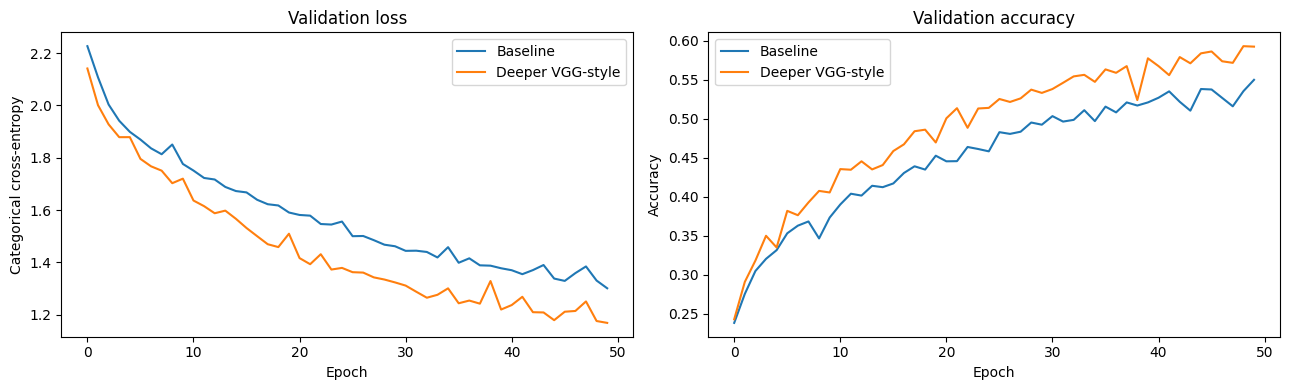

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for history, label in [(history_baseline, "Baseline"), (history_vgg, "Deeper VGG-style")]:
    axes[0].plot(history.history["val_loss"], label=label)
    axes[1].plot(history.history["val_accuracy"], label=label)
axes[0].set(title="Validation loss", xlabel="Epoch", ylabel="Categorical cross-entropy")
axes[1].set(title="Validation accuracy", xlabel="Epoch", ylabel="Accuracy")
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

**Comment on the observation**

The deeper VGG-style model performed better on the validation set: its final validation accuracy was 59.3%, compared with 55.0% for the baseline, and its validation loss was lower. The deeper model learned more useful image features, although its final training accuracy (62.4%) exceeded its validation accuracy (59.3%), indicating some overfitting. More depth helped here, but regularization and tuning could narrow that gap.

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


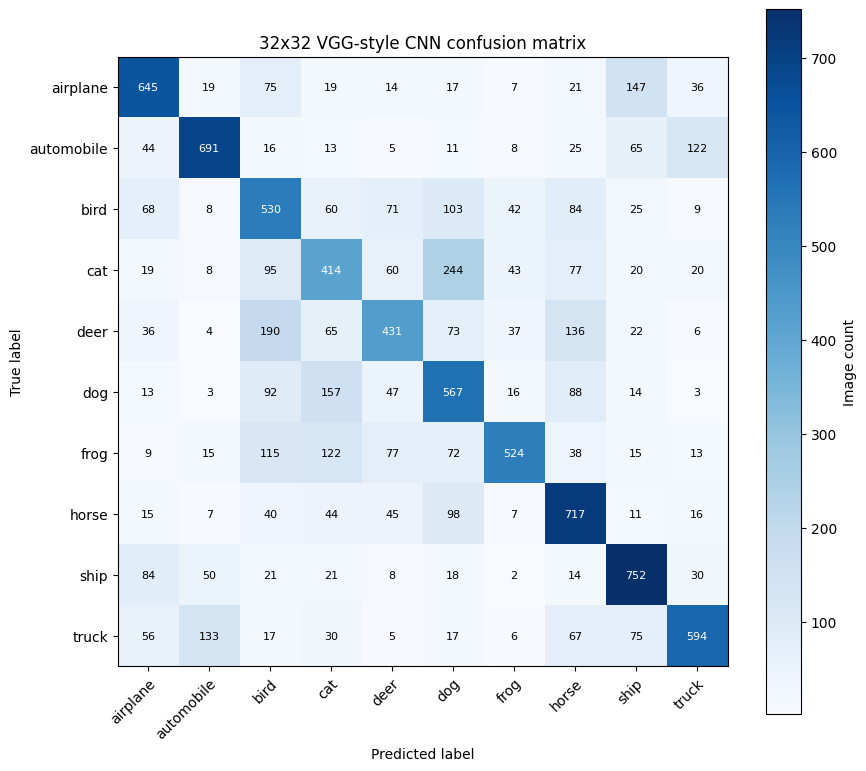

In [9]:
y_test_labels = np.argmax(y_test, axis=1)
y_pred_vgg = np.argmax(model.predict(x_test, batch_size=512, verbose=0), axis=1)
cm_vgg = tf.math.confusion_matrix(y_test_labels, y_pred_vgg, num_classes=10).numpy()

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(cm_vgg, cmap="Blues")
ax.set(
    xticks=np.arange(10),
    yticks=np.arange(10),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="32x32 VGG-style CNN confusion matrix",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
threshold = cm_vgg.max() / 2
for row in range(10):
    for column in range(10):
        ax.text(column, row, f"{cm_vgg[row, column]}", ha="center", va="center",
                color="white" if cm_vgg[row, column] > threshold else "black", fontsize=8)
fig.colorbar(image, ax=ax, label="Image count")
fig.tight_layout()
plt.show()

**Comment here:**

The model most often confused cats with dogs (244 cats as dogs and 157 dogs as cats). It also confused deer with birds (190) and horses (136), and airplanes with ships (147). These pairs share similar shapes, textures, or colors in small images, making fine-grained distinctions difficult at this resolution.

*    Print the test accuracy for the trained model.

In [10]:
test_loss_vgg, test_accuracy_vgg = model.evaluate(x_test, y_test, batch_size=512, verbose=0)
print(f"32x32 VGG-style test accuracy: {test_accuracy_vgg:.2%}")

confusion_counts = cm_vgg.copy()
np.fill_diagonal(confusion_counts, 0)
most_common_confusions = np.dstack(np.unravel_index(np.argsort(confusion_counts.ravel())[-5:], confusion_counts.shape))[0][::-1]
for true_class, predicted_class in most_common_confusions:
    print(f"{class_names[true_class]} predicted as {class_names[predicted_class]}: {cm_vgg[true_class, predicted_class]}")

32x32 VGG-style test accuracy: 58.65%
cat predicted as dog: 244
deer predicted as bird: 190
dog predicted as cat: 157
airplane predicted as ship: 147
deer predicted as horse: 136


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [15]:
from keras.backend import clear_session
clear_session()

In [11]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax", dtype="float32"),
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

Epoch 1/10
88/88 - 139s - 2s/step - accuracy: 0.1131 - loss: 2.2992 - val_accuracy: 0.1374 - val_loss: 2.2950
Epoch 2/10
88/88 - 13s - 150ms/step - accuracy: 0.1586 - loss: 2.2883 - val_accuracy: 0.1726 - val_loss: 2.2751
Epoch 3/10
88/88 - 13s - 153ms/step - accuracy: 0.1904 - loss: 2.2362 - val_accuracy: 0.2070 - val_loss: 2.1790
Epoch 4/10
88/88 - 14s - 161ms/step - accuracy: 0.2296 - loss: 2.1356 - val_accuracy: 0.2258 - val_loss: 2.1070
Epoch 5/10
88/88 - 14s - 164ms/step - accuracy: 0.2694 - loss: 2.0575 - val_accuracy: 0.3148 - val_loss: 1.9834
Epoch 6/10
88/88 - 14s - 159ms/step - accuracy: 0.3097 - loss: 1.9640 - val_accuracy: 0.3154 - val_loss: 1.9505
Epoch 7/10
88/88 - 14s - 156ms/step - accuracy: 0.3264 - loss: 1.9183 - val_accuracy: 0.3316 - val_loss: 1.9028
Epoch 8/10
88/88 - 14s - 155ms/step - accuracy: 0.3476 - loss: 1.8453 - val_accuracy: 0.3566 - val_loss: 1.8488
Epoch 9/10
88/88 - 14s - 156ms/step - accuracy: 0.3641 - loss: 1.7997 - val_accuracy: 0.3580 - val_loss: 1

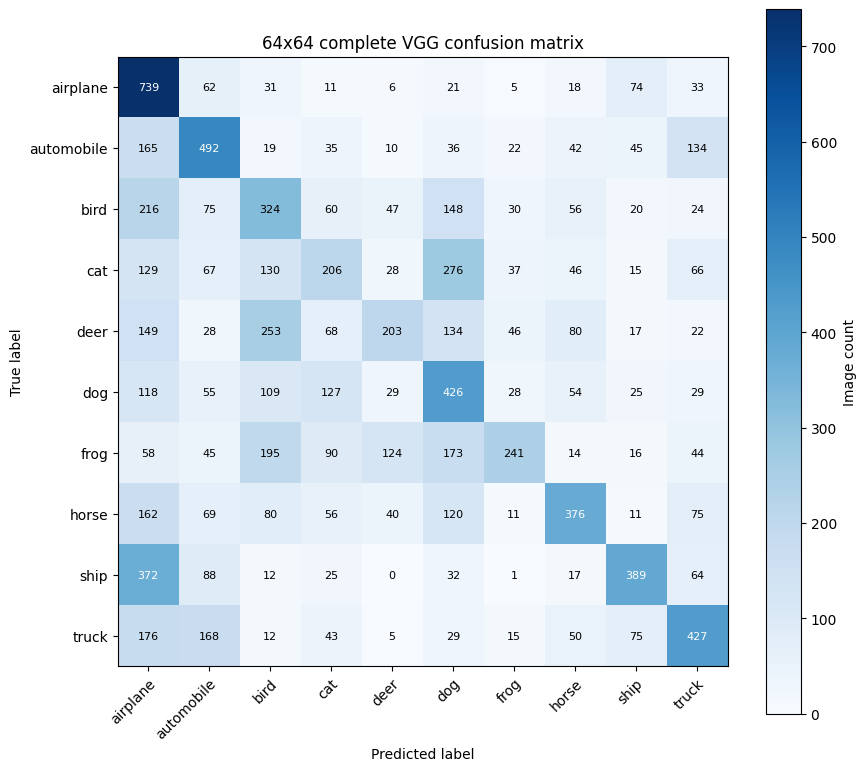

In [12]:
split_index = int(0.9 * len(x_train))

def resize_batch(images, labels):
    return tf.image.resize(images, (64, 64)), labels

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train[:split_index], y_train[:split_index]))
    .shuffle(10000, seed=42)
    .batch(512)
    .map(resize_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((x_train[split_index:], y_train[split_index:]))
    .batch(512)
    .map(resize_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(512)
    .map(resize_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

model.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history_vgg64 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=2,
)

y_pred_vgg64 = np.argmax(model.predict(test_ds, verbose=0), axis=1)
cm_vgg64 = tf.math.confusion_matrix(y_test_labels, y_pred_vgg64, num_classes=10).numpy()
test_accuracy_vgg64 = np.mean(y_pred_vgg64 == y_test_labels)
print(f"64x64 complete VGG test accuracy: {test_accuracy_vgg64:.2%}")

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(cm_vgg64, cmap="Blues")
ax.set(
    xticks=np.arange(10),
    yticks=np.arange(10),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="64x64 complete VGG confusion matrix",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
threshold = cm_vgg64.max() / 2
for row in range(10):
    for column in range(10):
        ax.text(column, row, f"{cm_vgg64[row, column]}", ha="center", va="center",
                color="white" if cm_vgg64[row, column] > threshold else "black", fontsize=8)
fig.colorbar(image, ax=ax, label="Image count")
fig.tight_layout()
plt.show()

In [13]:
confusion_counts_64 = cm_vgg64.copy()
np.fill_diagonal(confusion_counts_64, 0)
most_common_confusions_64 = np.dstack(
    np.unravel_index(np.argsort(confusion_counts_64.ravel())[-5:], confusion_counts_64.shape)
)[0][::-1]
for true_class, predicted_class in most_common_confusions_64:
    print(f"{class_names[true_class]} predicted as {class_names[predicted_class]}: {cm_vgg64[true_class, predicted_class]}")

ship predicted as airplane: 372
cat predicted as dog: 276
deer predicted as bird: 253
bird predicted as airplane: 216
frog predicted as bird: 195


**64x64 VGG confusion observation**

The most frequent errors were ships classified as airplanes (372), cats as dogs (276), deer as birds (253), birds as airplanes (216), and frogs as birds (195). Similar silhouettes and textures remain challenging. The 10-epoch test accuracy was 38.23%; this deeper model likely needs more training and tuning before it can outperform the shallower model.

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:

Activation functions introduce nonlinearity into a neural network. Without them, stacking layers would still produce only a linear transformation, limiting the patterns the network could learn. ReLU is commonly used in hidden layers, while an output activation is chosen to match the prediction task.

2 - Key Differences between sigmoid and softmax:

Sigmoid independently maps each output to a value between 0 and 1, so multiple outputs can be active at once; it suits binary or multilabel classification. Softmax converts a vector of logits into probabilities that sum to 1, making classes compete; it suits mutually exclusive multiclass classification, as in CIFAR-10.

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

Categorical crossentropy compares a probability distribution over mutually exclusive classes with one-hot class labels (sparse categorical crossentropy accepts integer labels). Binary crossentropy evaluates each output independently as a binary target and is suited to binary or multilabel tasks, where more than one class may be true.